# Dataset Introduction

One-page overview dashboard per dataset - sits right after data cleaning, before EDA or modeling. Charts are chosen for what's worth discussing in a presentation, not just generic distributions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

sns.set_style("whitegrid")

listings = pd.read_csv("../data/processed/cleaned_listings.csv")
users = pd.read_csv("../data/processed/cleaned_users.csv")
scheme = pd.read_csv("../data/raw/historical_scheme_data.csv")

def stat_card(ax, value, label, size=19, color="#eef2f7", accent="#2c6fbb"):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    box = FancyBboxPatch((0.04, 0.08), 0.92, 0.84,
                          boxstyle="round,pad=0.02,rounding_size=0.06",
                          linewidth=1.6, edgecolor=accent, facecolor=color,
                          transform=ax.transAxes)
    ax.add_patch(box)
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=size, fontweight="bold", color="#1a1a1a")
    ax.text(0.5, 0.28, label, ha="center", va="center", fontsize=10.5, color="#555555")
    ax.axis("off")


---

## 1. Property Listings — Overview Dashboard
*(used for Price Prediction)*

**Insights covered:** price is right-skewed (why we model log-price), property type
and city are the two biggest price drivers, area scales price roughly linearly,
specific amenities and new-vs-resale status carry a real price premium.

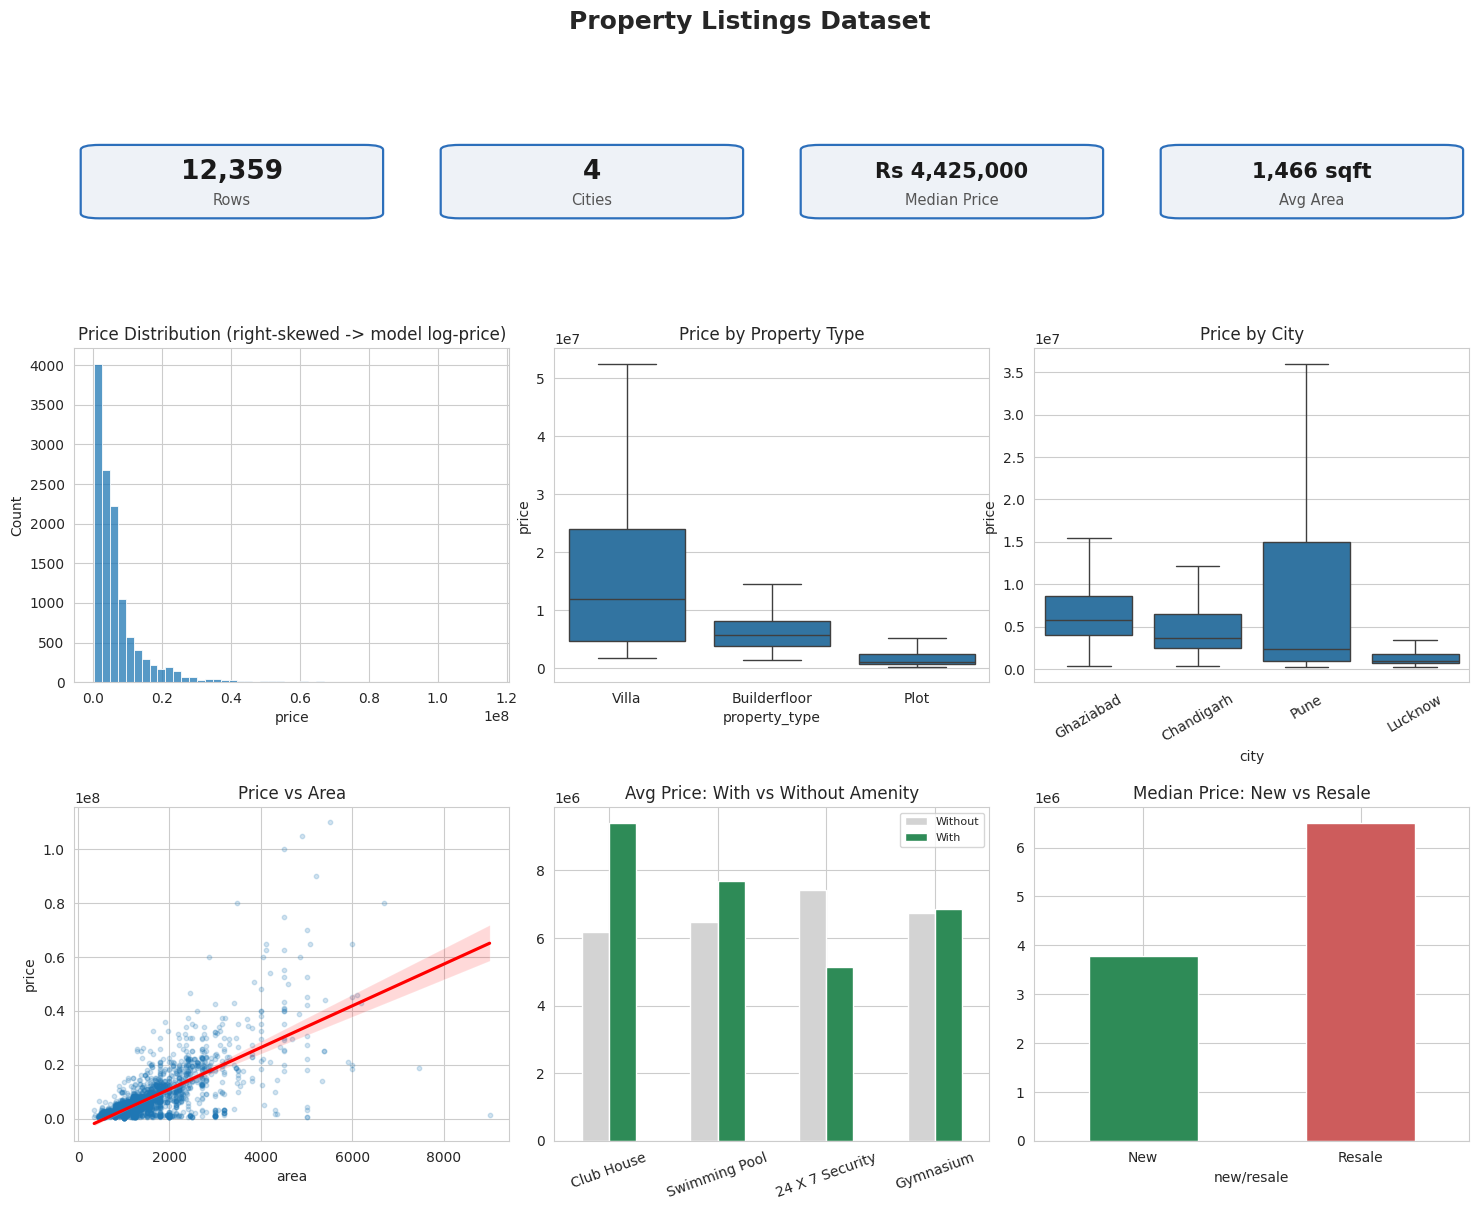

In [2]:
fig = plt.figure(figsize=(18, 13))
gs = gridspec.GridSpec(3, 12, figure=fig, height_ratios=[0.5, 2, 2], hspace=0.5, wspace=0.6)
fig.suptitle("Property Listings Dataset", fontsize=18, fontweight="bold", y=0.98)

stat_card(fig.add_subplot(gs[0, 0:3]), f"{listings.shape[0]:,}", "Rows")
stat_card(fig.add_subplot(gs[0, 3:6]), f"{listings['city'].nunique()}", "Cities")
stat_card(fig.add_subplot(gs[0, 6:9]), f"Rs {listings['price'].median():,.0f}", "Median Price", size=15)
stat_card(fig.add_subplot(gs[0, 9:12]), f"{listings['area'].mean():,.0f} sqft", "Avg Area", size=15)

ax = fig.add_subplot(gs[1, 0:4])
sns.histplot(listings["price"], bins=50, ax=ax)
ax.set_title("Price Distribution (right-skewed -> model log-price)")

ax = fig.add_subplot(gs[1, 4:8])
order = listings.groupby("property_type")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=listings, x="property_type", y="price", order=order, showfliers=False, ax=ax)
ax.set_title("Price by Property Type")

ax = fig.add_subplot(gs[1, 8:12])
order = listings.groupby("city")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=listings, x="city", y="price", order=order, showfliers=False, ax=ax)
ax.set_title("Price by City"); ax.tick_params(axis="x", rotation=30)

ax = fig.add_subplot(gs[2, 0:4])
sample = listings.sample(min(3000, len(listings)), random_state=1)
sns.regplot(data=sample, x="area", y="price", scatter_kws={"alpha":0.2,"s":10}, line_kws={"color":"red"}, ax=ax)
ax.set_title("Price vs Area")

ax = fig.add_subplot(gs[2, 4:8])
key_amenities = ["Club House", "Swimming Pool", "24 X 7 Security", "Gymnasium"]
premium = pd.DataFrame({
    a: [listings.loc[listings[a]==0, "price"].mean(), listings.loc[listings[a]==1, "price"].mean()]
    for a in key_amenities
}, index=["Without", "With"]).T
premium.plot(kind="bar", ax=ax, color=["lightgray", "seagreen"])
ax.set_title("Avg Price: With vs Without Amenity"); ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[2, 8:12])
new_resale = listings.groupby(listings["new/resale"].map({1:"New",0:"Resale"}))["price"].median()
new_resale.plot(kind="bar", ax=ax, color=["seagreen","indianred"])
ax.set_title("Median Price: New vs Resale"); ax.tick_params(axis="x", rotation=0)

plt.show()


---

## 2. Customer Survey — Overview Dashboard
*(used for Purchase Intent)*

**Insights covered:** site visits and prior enquiries are the strongest behavioural
predictors of purchase, income tracks with intent, investment buyers convert
differently than self-use buyers, and purchase rate varies notably by city.

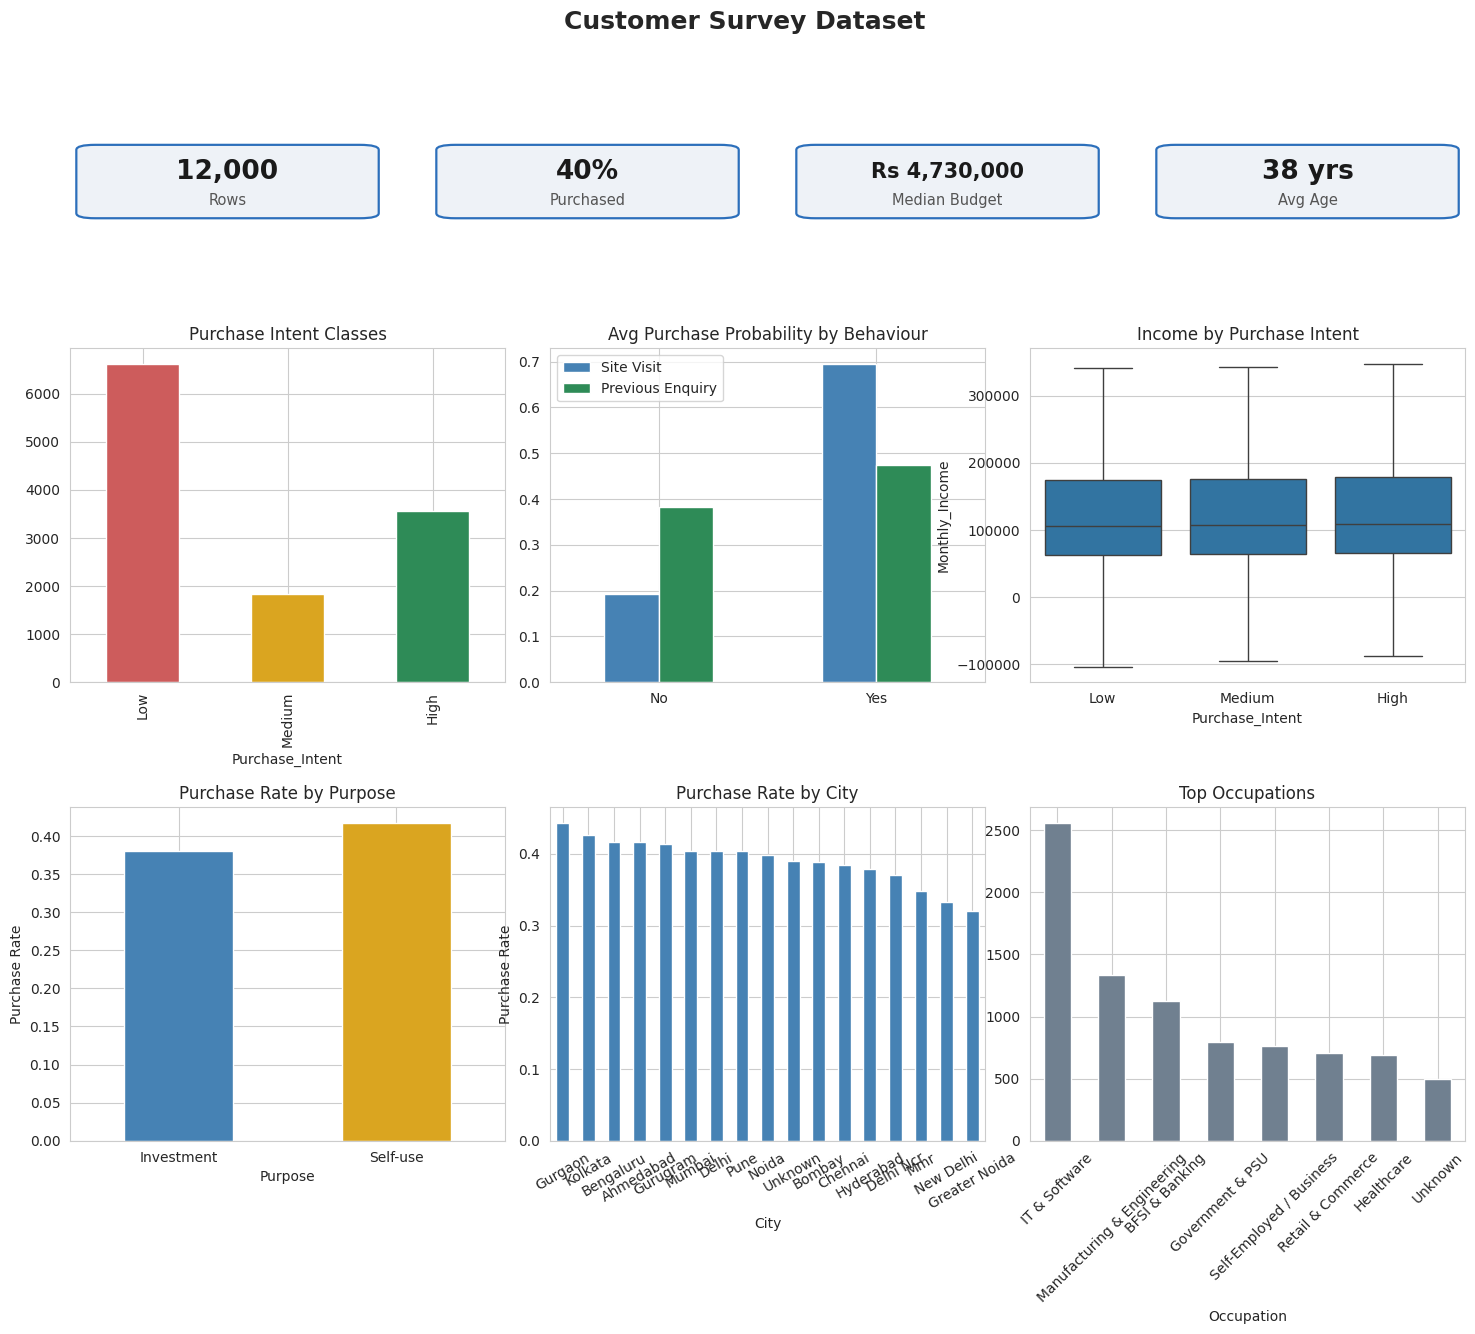

In [3]:
fig = plt.figure(figsize=(18, 13))
gs = gridspec.GridSpec(3, 12, figure=fig, height_ratios=[0.5, 2, 2], hspace=0.5, wspace=0.6)
fig.suptitle("Customer Survey Dataset", fontsize=18, fontweight="bold", y=0.98)

stat_card(fig.add_subplot(gs[0, 0:3]), f"{users.shape[0]:,}", "Rows")
stat_card(fig.add_subplot(gs[0, 3:6]), f"{(users['Purchased']=='Yes').mean():.0%}", "Purchased")
stat_card(fig.add_subplot(gs[0, 6:9]), f"Rs {users['Plot_Budget'].median():,.0f}", "Median Budget", size=15)
stat_card(fig.add_subplot(gs[0, 9:12]), f"{users['Age'].mean():.0f} yrs", "Avg Age")

ax = fig.add_subplot(gs[1, 0:4])
users["Purchase_Intent"].value_counts().reindex(["Low","Medium","High"]).plot(
    kind="bar", ax=ax, color=["indianred","goldenrod","seagreen"])
ax.set_title("Purchase Intent Classes")

ax = fig.add_subplot(gs[1, 4:8])
site_visit_rate = users.groupby("Site_Visit")["Purchase_Probability"].mean()
enquiry_rate = users.groupby("Previous_Enquiry")["Purchase_Probability"].mean()
behaviour = pd.DataFrame({"Site Visit": site_visit_rate, "Previous Enquiry": enquiry_rate})
behaviour.plot(kind="bar", ax=ax, color=["steelblue","seagreen"])
ax.set_title("Avg Purchase Probability by Behaviour"); ax.tick_params(axis="x", rotation=0)

ax = fig.add_subplot(gs[1, 8:12])
sns.boxplot(data=users, x="Purchase_Intent", y="Monthly_Income", order=["Low","Medium","High"], showfliers=False, ax=ax)
ax.set_title("Income by Purchase Intent")

ax = fig.add_subplot(gs[2, 0:4])
purchase_by_purpose = users.groupby("Purpose")["Purchased"].apply(lambda x: (x=="Yes").mean())
purchase_by_purpose.plot(kind="bar", ax=ax, color=["steelblue","goldenrod"])
ax.set_title("Purchase Rate by Purpose"); ax.tick_params(axis="x", rotation=0)
ax.set_ylabel("Purchase Rate")

ax = fig.add_subplot(gs[2, 4:8])
purchase_by_city = users.groupby("City")["Purchased"].apply(lambda x: (x=="Yes").mean()).sort_values(ascending=False)
purchase_by_city.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Purchase Rate by City"); ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Purchase Rate")

ax = fig.add_subplot(gs[2, 8:12])
users["Occupation"].value_counts().head(8).plot(kind="bar", ax=ax, color="slategray")
ax.set_title("Top Occupations"); ax.tick_params(axis="x", rotation=45)

plt.show()


---

## 3. Scheme Records — Overview Dashboard
*(used for Scheme Success)*

**Insights covered:** success score varies substantially by location, proximity to
metro is a strong driver, advertising spend correlates with leads generated but with
diminishing returns, and having a Park or Clubhouse lifts the success score.

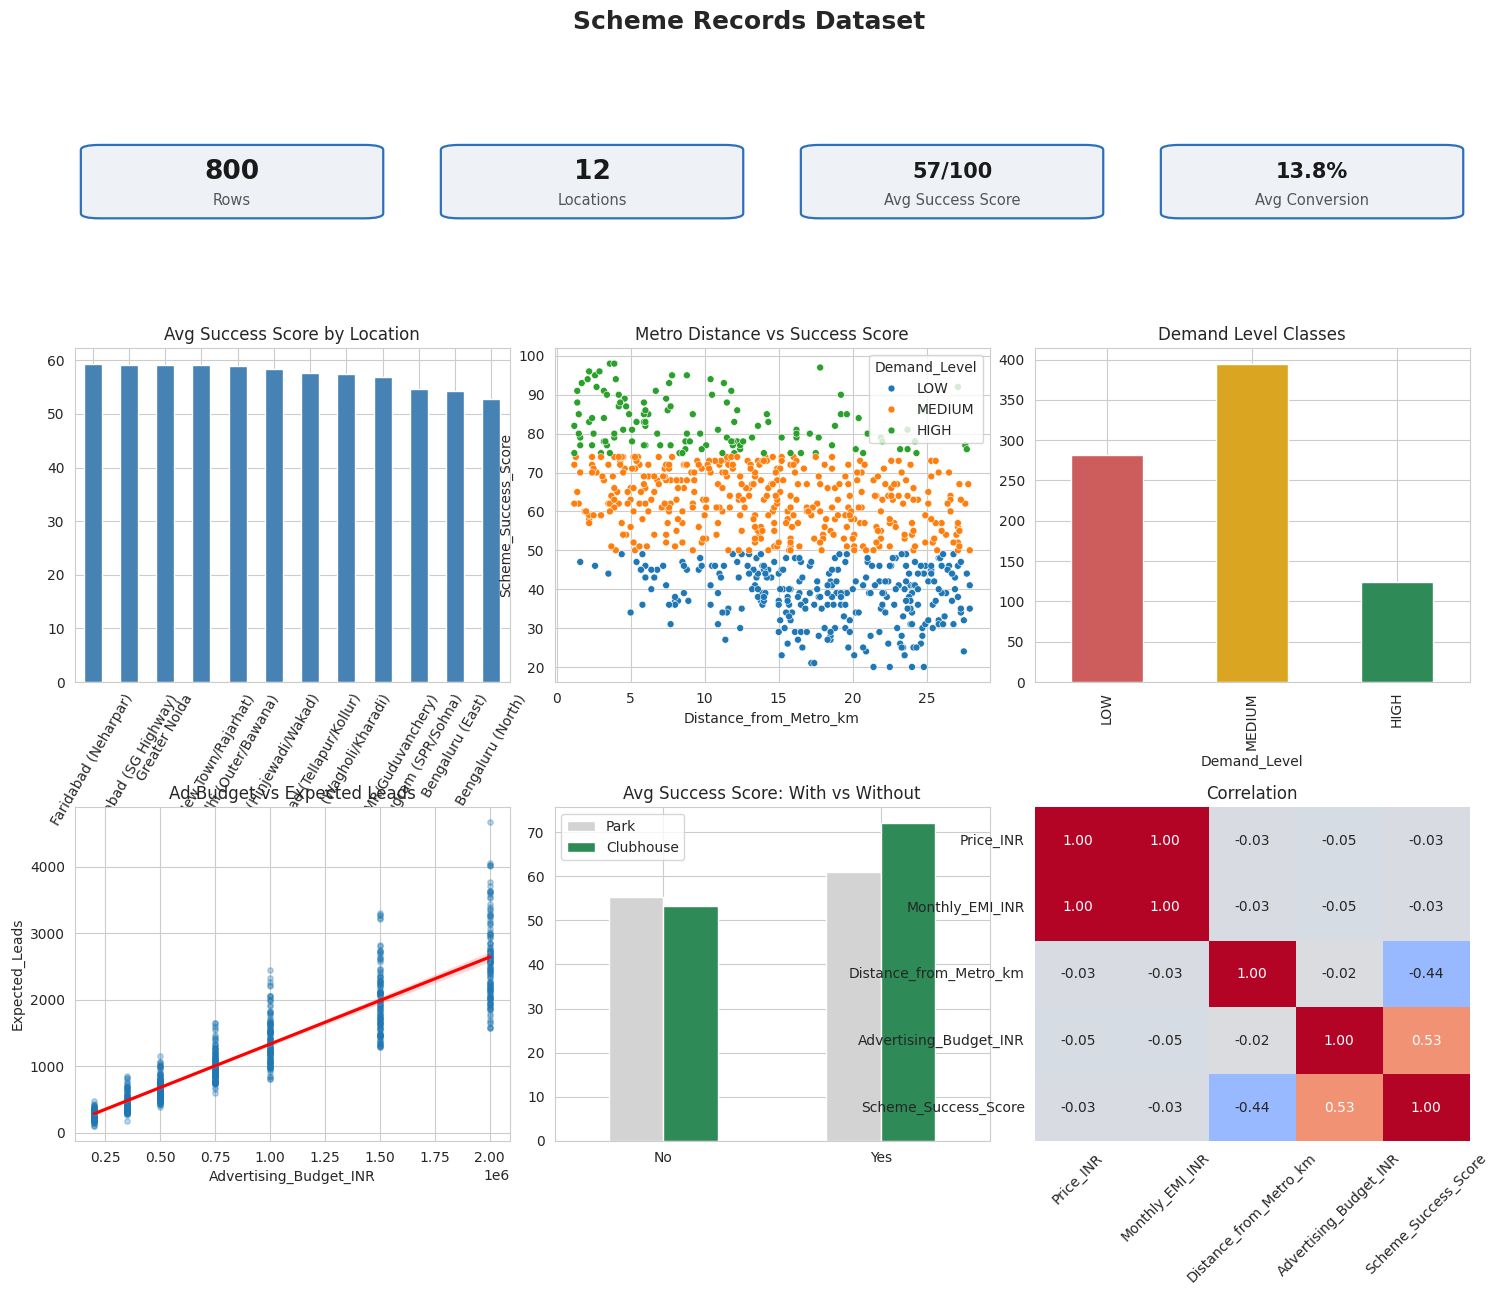

In [4]:
fig = plt.figure(figsize=(18, 13))
gs = gridspec.GridSpec(3, 12, figure=fig, height_ratios=[0.5, 2, 2], hspace=0.5, wspace=0.6)
fig.suptitle("Scheme Records Dataset", fontsize=18, fontweight="bold", y=0.98)

stat_card(fig.add_subplot(gs[0, 0:3]), f"{scheme.shape[0]:,}", "Rows")
stat_card(fig.add_subplot(gs[0, 3:6]), f"{scheme['Location'].nunique()}", "Locations")
stat_card(fig.add_subplot(gs[0, 6:9]), f"{scheme['Scheme_Success_Score'].mean():.0f}/100", "Avg Success Score", size=15)
stat_card(fig.add_subplot(gs[0, 9:12]), f"{scheme['Estimated_Conversion_Pct'].mean():.1f}%", "Avg Conversion", size=15)

ax = fig.add_subplot(gs[1, 0:4])
order = scheme.groupby("Location")["Scheme_Success_Score"].mean().sort_values(ascending=False).index
scheme.groupby("Location")["Scheme_Success_Score"].mean().reindex(order).plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Avg Success Score by Location"); ax.tick_params(axis="x", rotation=60)

ax = fig.add_subplot(gs[1, 4:8])
sns.scatterplot(data=scheme, x="Distance_from_Metro_km", y="Scheme_Success_Score", hue="Demand_Level",
                 hue_order=["LOW","MEDIUM","HIGH"], ax=ax, s=25)
ax.set_title("Metro Distance vs Success Score")

ax = fig.add_subplot(gs[1, 8:12])
scheme["Demand_Level"].value_counts().reindex(["LOW","MEDIUM","HIGH"]).plot(
    kind="bar", ax=ax, color=["indianred","goldenrod","seagreen"])
ax.set_title("Demand Level Classes")

ax = fig.add_subplot(gs[2, 0:4])
sns.regplot(data=scheme, x="Advertising_Budget_INR", y="Expected_Leads",
            scatter_kws={"alpha":0.3,"s":15}, line_kws={"color":"red"}, ax=ax)
ax.set_title("Ad Budget vs Expected Leads")

ax = fig.add_subplot(gs[2, 4:8])
park_score = scheme.groupby("Park")["Scheme_Success_Score"].mean().reindex(["No","Yes"])
clubhouse_score = scheme.groupby("Clubhouse")["Scheme_Success_Score"].mean().reindex(["No","Yes"])
amenity_df = pd.DataFrame({"Park": park_score, "Clubhouse": clubhouse_score})
amenity_df.plot(kind="bar", ax=ax, color=["lightgray","seagreen"])
ax.set_title("Avg Success Score: With vs Without"); ax.tick_params(axis="x", rotation=0)

ax = fig.add_subplot(gs[2, 8:12])
num_cols = ["Price_INR","Monthly_EMI_INR","Distance_from_Metro_km","Advertising_Budget_INR","Scheme_Success_Score"]
sns.heatmap(scheme[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar=False)
ax.set_title("Correlation"); ax.tick_params(axis="x", rotation=45)

plt.show()


---

## Summary

In [5]:
summary = pd.DataFrame({
    "Dataset": ["Property Listings", "Customer Survey", "Scheme Records"],
    "Used For": ["Price Prediction", "Purchase Intent", "Scheme Success"],
    "Rows": [listings.shape[0], users.shape[0], scheme.shape[0]],
    "Columns": [listings.shape[1], users.shape[1], scheme.shape[1]],
    "Missing %": [listings.isna().mean().mean()*100, users.isna().mean().mean()*100, scheme.isna().mean().mean()*100],
}).round(2).set_index("Dataset")
summary


,Used For,Rows,Columns,Missing %
Dataset,,,,
Property Listings,Price Prediction,12359,28,0.12
Customer Survey,Purchase Intent,12000,25,0.00
Scheme Records,Scheme Success,800,16,0.00
